       quantity  numerical  analytical  error(%)
flight time (s)   2.890000    2.883208  0.235568
       range(m)  40.916035   40.774720  0.346575


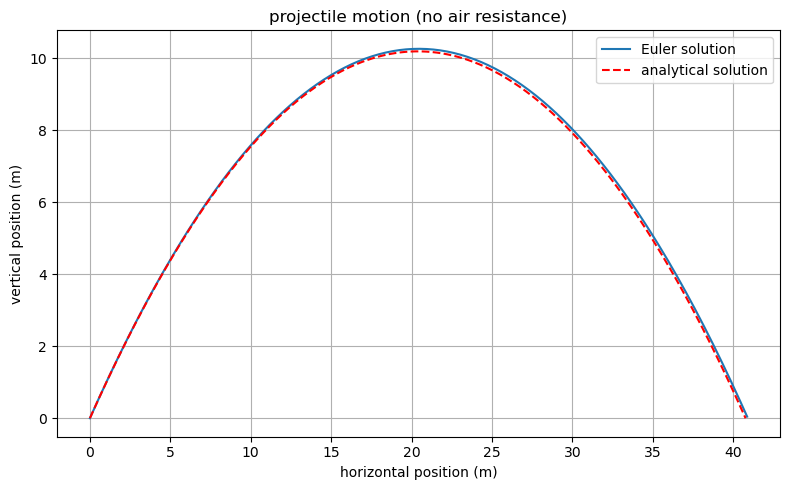

In [8]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

# ====== physical parameters ======

g = 9.81                         # gravitational acceleration (m/s^2)
v0= 20                           # initial velocity (m/s)
angle_deg = 45                   # launch angle (degrees)
theta = np.radians(angle_deg)    
dt = 0.01                       # time step (s) 

# ====== initial conditions ======

vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

x = 0.0
y = 0.0

x_values = [x]
y_values = [y]

# ====== acceleration ======

ax = 0.0
ay = -g

# === numerical simulation using Euler's method ===

while y >= 0 :
    x_new = x + vx * dt 
    y_new = y + vy * dt
# interpolate to estimate the exact landing position 
    if y_new < 0 :
        f = y / (y - y_new)
        x_impact = x + f * (x_new - x )
        range_numerical = x_impact
        break
        
    vx_new = vx + ax *dt
    vy_new = vy + ay * dt
    # update position and velocity
    x = x_new
    y = y_new
    vx = vx_new
    vy = vy_new
    # store trajectory 
    x_values.append(x)
    y_values.append(y)  

# === analytical solution ===

flight_time_exact = 2 * v0 * np.sin(theta) / g
range_exact = v0 ** 2 * np.sin(2*theta) / g 
# numerical vs analytical results 
flight_time_numerical = (len(y_values) - 1) * dt

time_error = (abs(flight_time_numerical - flight_time_exact ) / flight_time_exact ) * 100
range_error = (abs(range_numerical - range_exact) / range_exact ) * 100

results = pd.DataFrame({"quantity" : ["flight time (s)","range(m)"] , 
                        "numerical" : [flight_time_numerical , range_numerical] ,
                        "analytical" : [flight_time_exact , range_exact] ,
                       "error(%)" : [time_error , range_error]})
print(results.to_string(index = False))

# ====== analytical trajectory ======

x_exact = np.linspace(0 , range_exact , 500)
y_exact = ( x_exact * np.tan(theta) - (g * x_exact**2)/(2* v0**2 * np.cos(theta)**2) )

# ====== visualization ====== 

plt.figure(figsize = (8,5))
plt.plot( x_values , y_values , label='Euler solution')
plt.plot(x_exact , y_exact , '--',color = 'red' , label = 'analytical solution' )
plt.title('projectile motion (no air resistance)')
plt.xlabel('horizontal position (m)')
plt.ylabel('vertical position (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('projectile_trajectory.png' , dpi = 300 , bbox_inches = 'tight')
plt.show()   
